# Module 15: Agricultural Data Analytics (The KPK Context)
## Objective: Applying Data Science to KPK's Agricultural Backbone.

In this module, we bridge the gap between high-level code and the soil of 
Khyber Pakhtunkhwa. We will explore how IoT sensors, satellite imagery, 
and predictive modeling can revolutionize the orchards of Swat and the 
tobacco fields of Mardan.

### 1. Precision Agriculture: Sensor Data Analysis
In precision agriculture, we monitor **NPK levels** and **Moisture**. 
If moisture drops below a certain threshold, an automated irrigation 
system can be triggered.

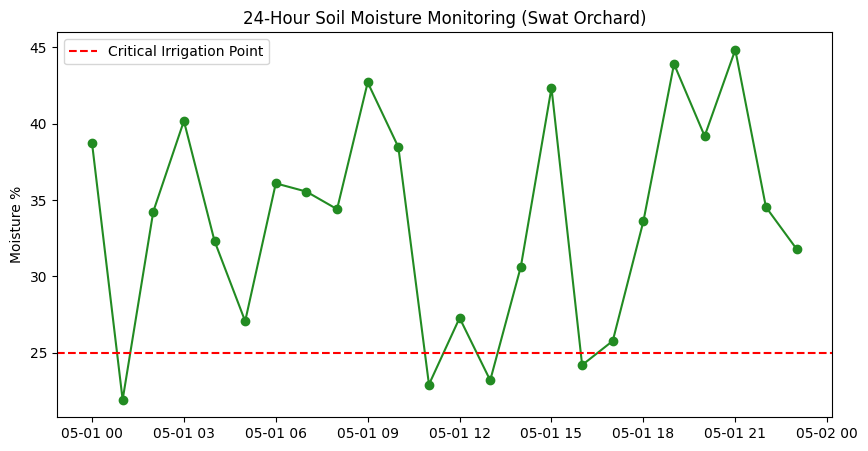

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate 24 hours of sensor data from a Swat Peach Orchard
# Change "H" to "h"
time_slots = pd.date_range("2024-05-01", periods=24, freq="h")
data = {
    'Moisture_Level': np.random.uniform(20, 45, 24),
    'Soil_pH': np.random.uniform(6.0, 7.5, 24),
    'Nitrogen_ppm': np.random.uniform(15, 25, 24)
}
orchard_df = pd.DataFrame(data, index=time_slots)

# Visualization: Monitoring Moisture Thresholds
plt.figure(figsize=(10, 5))
plt.plot(orchard_df['Moisture_Level'], marker='o', color='forestgreen')
plt.axhline(y=25, color='red', linestyle='--', label='Critical Irrigation Point')
plt.title("24-Hour Soil Moisture Monitoring (Swat Orchard)")
plt.ylabel("Moisture %")
plt.legend()
plt.show()

### 2. Satellite & GIS Integration
**GeoPandas** extends the capabilities of Pandas to allow spatial operations 
on geometric types. We use it to map crop health across different coordinates.

In [16]:
# pip install geopandas -q

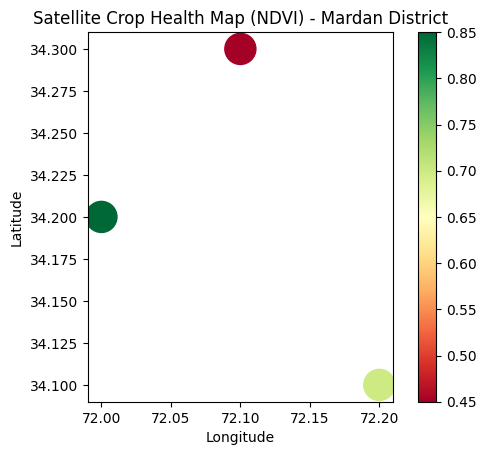

In [17]:
import geopandas as gpd
from shapely.geometry import Point

# Simulate 3 coordinates in Mardan with 'Health Scores' (NDVI)
d = {'District': ['Mardan_North', 'Mardan_South', 'Mardan_East'],
     'NDVI_Score': [0.85, 0.45, 0.70], # 0.8 is healthy, 0.4 is stressed
     'geometry': [Point(72.0, 34.2), Point(72.1, 34.3), Point(72.2, 34.1)]}

gdf = gpd.GeoDataFrame(d, crs="EPSG:4326")

# Plotting the 'Health' of different zones
gdf.plot(column='NDVI_Score', legend=True, cmap='RdYlGn', markersize=500)
plt.title("Satellite Crop Health Map (NDVI) - Mardan District")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### 3. Yield Prediction: Wheat & Sugarcane
We use historical correlations to predict future totals. For example, 
if Rainfall increases by 10%, how does it affect Wheat tonnage?

In [18]:
# Historical Data: Rainfall (mm) vs Wheat Yield (Tons per Hectare)
import pandas as pd
history = pd.DataFrame({
    'Rainfall_mm': [100, 150, 120, 200, 180, 90, 110],
    'Yield_Tons': [2.5, 3.8, 3.0, 4.5, 4.1, 2.1, 2.7]
})

# Quick correlation check
correlation = history.corr().iloc[0, 1]
print(f"Correlation between Rainfall and Wheat Yield: {correlation:.2f}")

# Simple Prediction Logic
def predict_yield(rain):
    # Simplified linear model based on historical trend
    return rain * 0.022 

current_forecast_rain = 160
predicted_harvest = predict_yield(current_forecast_rain)
print(f"Predicted Wheat Yield for 160mm Rainfall: {predicted_harvest:.2f} Tons/Hectare")

Correlation between Rainfall and Wheat Yield: 0.99
Predicted Wheat Yield for 160mm Rainfall: 3.52 Tons/Hectare


### 4. Spatial Pest Tracking
By mapping reported sightings of pests, we can create heatmaps to alert 
nearby districts like Charsadda or Nowshera.

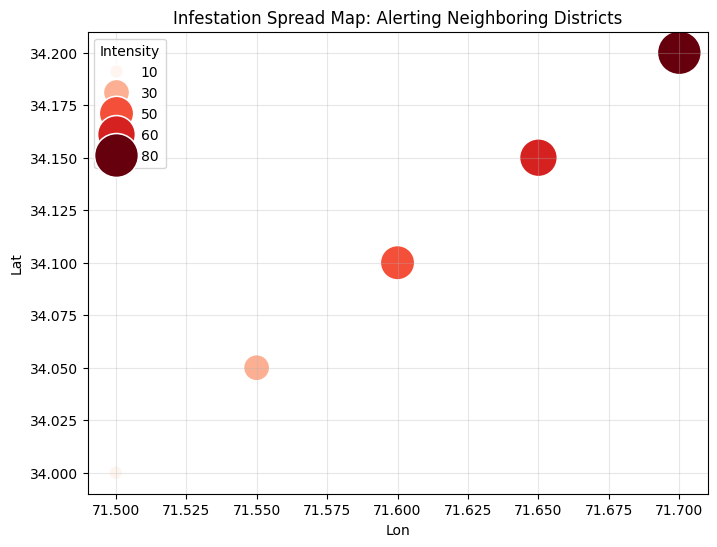

In [20]:
# Sighting coordinates of a specific pest
import pandas as pd
pest_sightings = pd.DataFrame({
    'Lat': [34.0, 34.1, 34.05, 34.2, 34.15],
    'Lon': [71.5, 71.6, 71.55, 71.7, 71.65],
    'Intensity': [10, 50, 30, 80, 60]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pest_sightings, x='Lon', y='Lat', size='Intensity', 
                hue='Intensity', palette='Reds', sizes=(100, 1000))
plt.title("Infestation Spread Map: Alerting Neighboring Districts")
plt.grid(True, alpha=0.3)
plt.show()

### Student Exercise: The Smart Orchard Manager
**Goal**: Build a mini-system to monitor and predict orchard health in Swat.
1. Create a DataFrame for 5 different farm coordinates in Swat.
2. Generate random **pH levels** (5.0 to 8.5) and **Temperature** (15 to 40).
3. Identify which coordinates have "Acidic Soil" (pH < 6.0).
4. Create a **Scatter Plot** where the size of the point represents the 
   Temperature and the color represents the pH level.
5. Write a function that recommends "Lime Treatment" if pH is below 6.0.